In [1]:
import sys, json, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
BAD, GOOD, NEUTRAL, ACCENT = "#c0392b", "#1e8449", "#7f8c8d", "#2c6fbb"
RES = "../data/results/"


# 30 - The experiment audit
**ShopKart ran 40 A/B tests a quarter. How many shipped 'wins' were real?** Simulated quarters with known ground truth, analysed by a naive and a rigorous analyst. All money figures rest on assumptions in `config/audit_portfolio.yaml`.

In [2]:
s = pd.read_csv(RES + "audit_summary.csv", index_col=0)
res = json.load(open(RES + "audit_results.json"))
print("quarters simulated:", res["n_quarters"], " experiments per quarter:", res["experiments_per_quarter"])
s.T

quarters simulated: 500  experiments per quarter: 40


analyst,naive,rigorous
shipped_median,2.100000e+01,1.100000e+01
false_wins_median,9.000000e+00,2.000000e+00
fdr_median,4.583333e-01,1.666667e-01
true_wins_shipped_median,1.100000e+01,9.000000e+00
true_wins_missed_median,3.000000e+00,4.000000e+00
avg_reported_lift,2.087379e-01,1.208935e-01
avg_true_lift,6.020921e-02,1.006291e-01
cost_false_inr_median,4.500000e+06,1.000000e+06
cost_missed_inr_median,1.440000e+07,9.467078e+06
total_cost_inr_median,1.819622e+07,1.025330e+07


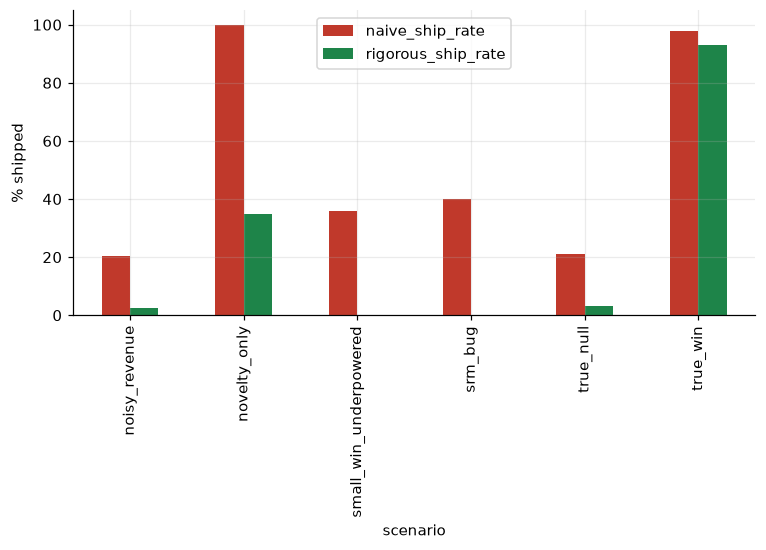

,n,naive_ship_rate,rigorous_ship_rate
scenario,,,
noisy_revenue,999,0.203,0.026
novelty_only,2056,1.000,0.348
small_win_underpowered,1965,0.358,0.000
srm_bug,1995,0.401,0.001
true_null,7969,0.212,0.031
true_win,5016,0.979,0.929


In [3]:
sc = pd.read_csv(RES + "audit_by_scenario.csv", index_col=0)
ax = sc[["naive_ship_rate", "rigorous_ship_rate"]].mul(100).plot.bar(color=[BAD, GOOD], figsize=(8, 3.6)); ax.set(ylabel="% shipped"); plt.show()
sc.round(3)

In [4]:
pd.DataFrame(res["sens_false_win_cost"])

,false_win_cost_inr,naive_total_cost_median,rigorous_total_cost_median
0,0,1.440000e+07,9.467078e+06
1,500000,1.819622e+07,1.025330e+07
2,2000000,3.320000e+07,1.424170e+07
3,5000000,6.092577e+07,2.100000e+07


In [5]:
print("worst case for rigorous (rerun = abandoned):", res["worst_case_rerun_equals_abandon"])
pd.DataFrame(res["sens_true_win_share"])

worst case for rigorous (rerun = abandoned): {'naive_total_cost_median': 18196221.177583553, 'rigorous_total_cost_median': 27827631.825610388}


,true_win_share,naive_fdr_median,rigorous_fdr_median,naive_false_wins_median,rigorous_false_wins_median,naive_total_cost_median,rigorous_total_cost_median
0,0.15,0.555556,0.250,10.0,2.0,19400000.0,8.550000e+06
1,0.35,0.350000,0.125,8.0,2.0,18400000.0,1.514715e+07


**So what:** see `reports/experiment_audit.md` for the full write-up, assumptions and limitations.